# Figure 2 burst compilation

Notebook-first assembly for Figure 2 based on `burst_analysis.ipynb` and the `stimRemovalNull` dataset. The notebook keeps the expensive burst-derived data in a cache, then uses composable plotting helpers for fast layout iteration.

In [1]:
%matplotlib inline

from pathlib import Path
from types import SimpleNamespace
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax import LayoutGridPlotter, PrepConfig, RestingActivityDataset
from ephax.metrics import (
    aggregate_wave_results,
    binned_kde_peak_summary,
    build_burst_peak_aligned_events,
    build_highres_traces,
    build_participation_activity_state,
    build_population_ifr,
    compute_or_load_wave_result,
    detect_high_activity_epochs,
    detect_participation_burst_epochs,
    extract_activity_state_ifr,
    load_wave_result_cache,
    save_wave_result_cache,
    wave_cache_dir,
)
from ephax.plotting import (
    PAPER_COLORS,
    apply_paper_style,
    compose_figure,
    draw_activity_state_ifr_kde_histograms,
    draw_grid_avghz_panel,
    draw_high_activity_burst_windows,
    draw_population_ifr_summary,
    draw_wave_bootstrap_panel,
    draw_wave_timing_panel,
    export_figure,
    figure,
    grid_avghz_panel_axes_factory,
    panel,
    population_ifr_summary_axes_factory,
)

apply_paper_style()
plt.rcParams["figure.dpi"] = 170
np.random.seed(0)

/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/danielrebbin/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Configuration and cache

Set `FORCE_RERUN = True` after changing analysis parameters. The cache stores only derived objects needed by the Figure 2 panels, not every intermediate high-resolution trace.

In [2]:
FORCE_RERUN = False
SAVE_FIGURE = True
CACHE_VERSION = "figure2_burst_v2_wave_div12"

DATA_ROOT = repo_root / "ephax/data/stimRemovalNull"
FILENAME_TEMPLATE = "DIV{div}_240703_data_well{well}_exp_data.npz"
OUTPUT_DIR = repo_root / "outputs" / "figure2_burst"
CACHE_PATH = OUTPUT_DIR / "figure2_burst_cache.pkl"
WAVE_CACHE_ROOT = repo_root / "outputs" / "stim_removal_null_wave_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WELLS = [0, 1, 2, 3, 4, 5]
DIVS = [12, 21]
EXAMPLE_WELL = 0
START_SEC = 0.0
END_SEC = 300.0
MIN_AMP = 0.0
TOP_START = 0
TOP_STOP = 1000

IFR_GRID_HZ = 50.0
IFR_MAX_HZ = 1000.0
SMOOTH_SIGMA_SEC = 0.15
HIGHRES_BIN_MS = 1.0
HIGHRES_SMOOTH_SIGMA_MS = 3.0
NETWORK_BIN_MS = 10.0
HIGH_ACTIVITY_MAD_SCALE = 3.0
HIGH_ACTIVITY_MIN_DURATION_MS = 30.0
HIGH_ACTIVITY_MAX_GAP_BINS = 0
NETWORK_MIN_PARTICIPATION_FRACTION = 0.05
NETWORK_MIN_DURATION_MS = 20.0
BURST_WINDOW_PAD_SEC = 0.40

WAVE_DIV = 12
WAVE_X_BIN_UM = 300.0
WAVE_PEAK_SEARCH_START_MS = -15.0
WAVE_PEAK_SEARCH_STOP_MS = 20.0
WAVE_TRACE_SMOOTH_SIGMA_MS = 2.0
WAVE_MIN_ELECTRODES_PER_BIN = 5
WAVE_MIN_EVENTS_PER_BIN = 5
WAVE_BOOTSTRAP_REPS = 2000
WAVE_RANDOM_SEED = 0
WAVE_FORCE_RECOMPUTE = False
AGGREGATE_WAVE_FORCE_RECOMPUTE = False

GRID_SIZE_UM = 50.0
GRID_INTERPOLATE = False

STATE_LABELS = {
    "low_activity": "Low activity",
    "high_activity": "High activity",
    "burst": "Burst",
}
STATE_COLORS = {
    "low_activity": PAPER_COLORS["low_activity"],
    "high_activity": PAPER_COLORS["high_activity"],
    "burst": PAPER_COLORS["burst"],
}

In [3]:
def recording_path(well, div):
    return DATA_ROOT / f"well{int(well)}" / FILENAME_TEMPLATE.format(div=int(div), well=int(well))


def recording_spec(well, div):
    path = recording_path(well, div)
    if not path.exists():
        raise FileNotFoundError(f"Missing stimRemovalNull file: {path}")
    return {
        "well": int(well),
        "div": int(div),
        "path": path,
        "recording_id": f"stimRemovalNull_well{int(well)}_DIV{int(div)}",
        "label": f"well {int(well)} DIV {int(div)}",
    }


def load_recording(spec):
    with np.load(spec["path"], allow_pickle=True) as data:
        sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
        frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
        rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
    file_info = [(str(spec["path"]), rec_t0 + START_SEC, rec_t0 + END_SEC, int(spec["well"]))]
    return RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(MIN_AMP))


def load_dataset_for_specs(specs):
    file_info = []
    for spec in specs:
        with np.load(spec["path"], allow_pickle=True) as data:
            sf_native = float(np.asarray(data["samp_rate"]).reshape(-1)[0])
            frameno = np.asarray(data["spike_data"]["frameno"], dtype=float)
            rec_t0 = float(np.min(frameno) / sf_native) if frameno.size else 0.0
        file_info.append((str(spec["path"]), rec_t0 + START_SEC, rec_t0 + END_SEC, int(spec["well"])))
    return RestingActivityDataset.from_file_info(file_info, source="npz", min_amp=float(MIN_AMP))


def select_refs(ds):
    prep = PrepConfig(mode="top", top_start=TOP_START, top_stop=TOP_STOP, verbose=False)
    return ds.select_ref_electrodes(prep)[0]


def slim_activity_state(activity):
    return SimpleNamespace(
        time_centers_s=np.asarray(activity.time_centers_s, dtype=float),
        participation_fraction=np.asarray(activity.participation_fraction, dtype=float),
    )

## Derived analysis objects

This follows the burst-analysis path, but returns compact panel-ready objects for Figure 2.

In [4]:
def build_single_recording_panels(well, div):
    spec = recording_spec(well, div)
    ds = load_recording(spec)
    rec = ds.recordings[0]
    refs = select_refs(ds)
    population = build_population_ifr(rec, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
    high_epochs, high_info = detect_high_activity_epochs(
        population.time_grid,
        population.mean_ifr_smooth,
        mad_scale=HIGH_ACTIVITY_MAD_SCALE,
        min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
        max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
    )
    highres = build_highres_traces(rec, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
    participation = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
    burst_epochs = detect_participation_burst_epochs(
        participation,
        high_epochs,
        min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
        min_duration_ms=NETWORK_MIN_DURATION_MS,
    )
    return {
        "spec": spec,
        "population": population,
        "high_activity_epochs": high_epochs,
        "high_activity_info": high_info,
        "participation_activity": slim_activity_state(participation),
        "burst_epochs": burst_epochs,
    }


def build_activity_kde_for_div(div):
    chunks = {"low_activity": [], "high_activity": [], "burst": []}
    rows = []
    for well in WELLS:
        spec = recording_spec(well, div)
        ds = load_recording(spec)
        rec = ds.recordings[0]
        refs = select_refs(ds)
        population = build_population_ifr(rec, refs, grid_hz=IFR_GRID_HZ, smooth_sigma_sec=SMOOTH_SIGMA_SEC)
        highres = build_highres_traces(rec, refs, bin_ms=HIGHRES_BIN_MS, smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS)
        high_epochs, high_info = detect_high_activity_epochs(
            population.time_grid,
            population.mean_ifr_smooth,
            mad_scale=HIGH_ACTIVITY_MAD_SCALE,
            min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
            max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
        )
        participation = build_participation_activity_state(highres, aggregation_ms=NETWORK_BIN_MS)
        burst_epochs = detect_participation_burst_epochs(
            participation,
            high_epochs,
            min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
            min_duration_ms=NETWORK_MIN_DURATION_MS,
        )
        state_values = extract_activity_state_ifr(rec, refs, high_epochs, burst_epochs, max_hz=IFR_MAX_HZ)
        for state, values in state_values.items():
            values = np.asarray(values, dtype=float)
            chunks[state].append(values[np.isfinite(values) & (values > 0) & (values <= IFR_MAX_HZ)])
        rows.append({
            "well": int(well),
            "div": int(div),
            "n_refs": int(len(refs)),
            "n_high_activity_periods": int(len(high_epochs)),
            "n_bursts": int(len(burst_epochs)),
            "high_activity_threshold_hz": float(high_info["threshold_hz"]),
        })
    values_by_state = {}
    for state, state_chunks in chunks.items():
        nonempty = [chunk for chunk in state_chunks if chunk.size]
        values_by_state[state] = np.concatenate(nonempty).astype(float) if nonempty else np.array([], dtype=float)
    kde_inputs = {
        "high_activity": values_by_state["high_activity"],
        "burst": values_by_state["burst"],
    }
    kde_results = {
        state: binned_kde_peak_summary(
            values,
            log_bins=True,
            n_bins=260,
            grid_size=8192,
            prominence_fraction=0.012,
            distance_fraction=0.006,
            bandwidth_scale=0.22,
            max_hz=IFR_MAX_HZ,
        )
        for state, values in kde_inputs.items()
    }
    return {
        "values": kde_inputs,
        "kde_results": kde_results,
        "summary": pd.DataFrame(rows),
        "source_label": f"stimRemovalNull wells 0-5, DIV {int(div)}",
    }


def build_grid_panel_for_div(div):
    specs = [recording_spec(well, div) for well in WELLS]
    ds = load_dataset_for_specs(specs)
    grids = LayoutGridPlotter(ds).compute_grid_avghz_per_recording(grid_size=GRID_SIZE_UM, interpolate=GRID_INTERPOLATE)
    titles = [f"well {well}" for well in WELLS]
    return {"grids": grids, "titles": titles}

def wave_settings():
    return {
        "x_bin_um": WAVE_X_BIN_UM,
        "peak_search_start_ms": WAVE_PEAK_SEARCH_START_MS,
        "peak_search_stop_ms": WAVE_PEAK_SEARCH_STOP_MS,
        "trace_smooth_sigma_ms": WAVE_TRACE_SMOOTH_SIGMA_MS,
        "bin_ms": HIGHRES_BIN_MS,
        "min_electrodes_per_bin": WAVE_MIN_ELECTRODES_PER_BIN,
        "min_events_per_bin": WAVE_MIN_EVENTS_PER_BIN,
        "bootstrap_reps": WAVE_BOOTSTRAP_REPS,
        "random_seed": WAVE_RANDOM_SEED,
    }


def build_aggregate_wave_for_div(div):
    settings = wave_settings()
    results_by_recording = []
    rows = []
    for well in WELLS:
        spec = recording_spec(well, div)
        recording_id = spec["recording_id"]
        cached = None if WAVE_FORCE_RECOMPUTE else load_wave_result_cache(wave_cache_dir(WAVE_CACHE_ROOT, recording_id, **settings))
        if cached is None:
            ds = load_recording(spec)
            rec = ds.recordings[0]
            refs = select_refs(ds)
            aligned, intermediates = build_burst_peak_aligned_events(
                rec,
                refs,
                ifr_grid_hz=IFR_GRID_HZ,
                smooth_sigma_sec=SMOOTH_SIGMA_SEC,
                highres_bin_ms=HIGHRES_BIN_MS,
                highres_smooth_sigma_ms=HIGHRES_SMOOTH_SIGMA_MS,
                network_bin_ms=NETWORK_BIN_MS,
                high_activity_mad_scale=HIGH_ACTIVITY_MAD_SCALE,
                high_activity_min_duration_ms=HIGH_ACTIVITY_MIN_DURATION_MS,
                high_activity_max_gap_bins=HIGH_ACTIVITY_MAX_GAP_BINS,
                network_min_participation_fraction=NETWORK_MIN_PARTICIPATION_FRACTION,
                network_min_duration_ms=NETWORK_MIN_DURATION_MS,
            )
            if len(pd.DataFrame(aligned.valid_anchors)) == 0:
                print(f"Skipping {recording_id}: no valid aligned burst anchors")
                continue
            result = compute_or_load_wave_result(
                recording_id,
                aligned,
                rec.layout,
                cache_root=WAVE_CACHE_ROOT,
                force=WAVE_FORCE_RECOMPUTE,
                **settings,
            )
            n_refs = int(len(refs))
            n_bursts = int(len(intermediates["burst_epochs"]))
        else:
            result = cached
            n_refs = np.nan
            n_bursts = int(result.fit_summary.iloc[0]["n_events_used"])

        results_by_recording.append((recording_id, result))
        fit = result.fit_summary.iloc[0]
        rows.append({
            "recording_id": recording_id,
            "well": int(well),
            "div": int(div),
            "n_refs": n_refs,
            "n_events_used": int(fit["n_events_used"]),
            "n_bursts_or_cached_events": n_bursts,
            "implied_speed_um_per_ms": float(fit["implied_speed_um_per_ms"]),
            "bootstrap_speed_mean_um_per_ms": float(fit["bootstrap_speed_mean_um_per_ms"]),
            "bootstrap_speed_median_um_per_ms": float(fit["bootstrap_speed_median_um_per_ms"]),
            "bootstrap_speed_ci_low_um_per_ms": float(fit["bootstrap_speed_ci_low_um_per_ms"]),
            "bootstrap_speed_ci_high_um_per_ms": float(fit["bootstrap_speed_ci_high_um_per_ms"]),
            "n_events_left_to_right": int(fit["n_events_left_to_right"]),
            "n_events_right_to_left": int(fit["n_events_right_to_left"]),
        })

    if not results_by_recording:
        raise ValueError(f"No aggregate wave results were available for DIV {div}.")

    aggregate_id = f"aggregate_stim_removal_null_wells{'-'.join(map(str, WELLS))}_DIVs{int(div)}"
    aggregate_cache_dir = wave_cache_dir(WAVE_CACHE_ROOT, aggregate_id, **settings)
    aggregate_result = None if AGGREGATE_WAVE_FORCE_RECOMPUTE else load_wave_result_cache(aggregate_cache_dir)
    if aggregate_result is None:
        aggregate_result, per_recording_fit = aggregate_wave_results(
            results_by_recording,
            x_bin_um=WAVE_X_BIN_UM,
            min_events_per_bin=WAVE_MIN_EVENTS_PER_BIN,
            bootstrap_reps=WAVE_BOOTSTRAP_REPS,
            random_seed=WAVE_RANDOM_SEED,
        )
        save_wave_result_cache(aggregate_result, aggregate_cache_dir)
    else:
        per_recording_fit = pd.concat(
            [result.fit_summary.assign(recording_id=recording_id) for recording_id, result in results_by_recording],
            ignore_index=True,
        )

    return {
        "result": aggregate_result,
        "summary": pd.DataFrame(rows),
        "per_recording_fit": per_recording_fit,
    }

In [5]:
def cache_is_current(payload):
    return (
        isinstance(payload, dict)
        and payload.get("cache_version") == CACHE_VERSION
        and payload.get("wells") == WELLS
        and payload.get("divs") == DIVS
        and payload.get("example_well") == EXAMPLE_WELL
        and payload.get("wave_div") == WAVE_DIV
        and "wave" in payload
    )


if CACHE_PATH.exists() and not FORCE_RERUN:
    with CACHE_PATH.open("rb") as f:
        figure2_data = pickle.load(f)
    if not cache_is_current(figure2_data):
        FORCE_RERUN = True

if FORCE_RERUN or not CACHE_PATH.exists():
    figure2_data = {
        "cache_version": CACHE_VERSION,
        "wells": WELLS,
        "divs": DIVS,
        "example_well": EXAMPLE_WELL,
        "wave_div": WAVE_DIV,
        "single": {div: build_single_recording_panels(EXAMPLE_WELL, div) for div in DIVS},
        "activity_kde": {div: build_activity_kde_for_div(div) for div in DIVS},
        "grid": {12: build_grid_panel_for_div(12)},
        "wave": {WAVE_DIV: build_aggregate_wave_for_div(WAVE_DIV)},
    }
    with CACHE_PATH.open("wb") as f:
        pickle.dump(figure2_data, f)

print(f"Loaded Figure 2 cache: {CACHE_PATH}")
for div in DIVS:
    single = figure2_data["single"][div]
    kde = figure2_data["activity_kde"][div]
    print(
        f"DIV {div}: well {EXAMPLE_WELL} high-activity periods={len(single['high_activity_epochs'])}, "
        f"bursts={len(single['burst_epochs'])}, aggregate samples="
        f"high={kde['values']['high_activity'].size:,}, burst={kde['values']['burst'].size:,}"
    )
wave = figure2_data["wave"][WAVE_DIV]
print(
    f"DIV {WAVE_DIV}: aggregate wave events={int(wave['result'].fit_summary.iloc[0]['n_events_used'])}, "
    f"speed={float(wave['result'].fit_summary.iloc[0]['implied_speed_um_per_ms']):.1f} um/ms"
)

Loaded Figure 2 cache: /Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure2_burst_cache.pkl
DIV 12: well 0 high-activity periods=14, bursts=64, aggregate samples=high=381,777, burst=143,366
DIV 21: well 0 high-activity periods=46, bursts=46, aggregate samples=high=99,831, burst=35,433
DIV 12: aggregate wave events=364, speed=809.3 um/ms


## Panel draw adapters

The adapters only bind Figure 2 options and keep the package draw functions reusable.

In [6]:
def high_activity_panel_data(div):
    single = figure2_data["single"][div]
    return {
        "time_grid": single["population"].time_grid,
        "mean_ifr": single["population"].mean_ifr,
        "mean_ifr_smooth": single["population"].mean_ifr_smooth,
        "network_activity": single["participation_activity"],
        "high_activity_epochs": single["high_activity_epochs"],
        "burst_epochs": single["burst_epochs"],
        "high_activity_threshold_hz": single["high_activity_info"]["threshold_hz"],
        "participation_threshold": NETWORK_MIN_PARTICIPATION_FRACTION,
    }


def side_by_side_kde_axes_factory(fig, subplotspec):
    gs = subplotspec.subgridspec(1, 2, wspace=0.34)
    return np.asarray([fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])], dtype=object)


def draw_activity_kde_panel(data, axes, **options):
    opts = dict(options)
    opts.setdefault("states", ("high_activity", "burst"))
    opts.setdefault("state_labels", STATE_LABELS)
    opts.setdefault("state_colors", STATE_COLORS)
    opts.setdefault("max_peak_labels", 6)
    opts.setdefault("hide_inner_xlabels", False)
    if opts.get("show_legend") is None:
        opts["show_legend"] = True
    return draw_activity_state_ifr_kde_histograms(
        data["kde_results"],
        axes,
        activity_values=data["values"],
        source_label=data["source_label"],
        **opts,
    )


def draw_grid_panel(data, axes, **options):
    opts = dict(options)
    opts.setdefault("recording_titles", data["titles"])
    opts.setdefault("show_colorbar", True)
    return draw_grid_avghz_panel(data["grids"], axes, **opts)

## Compose Figure 2

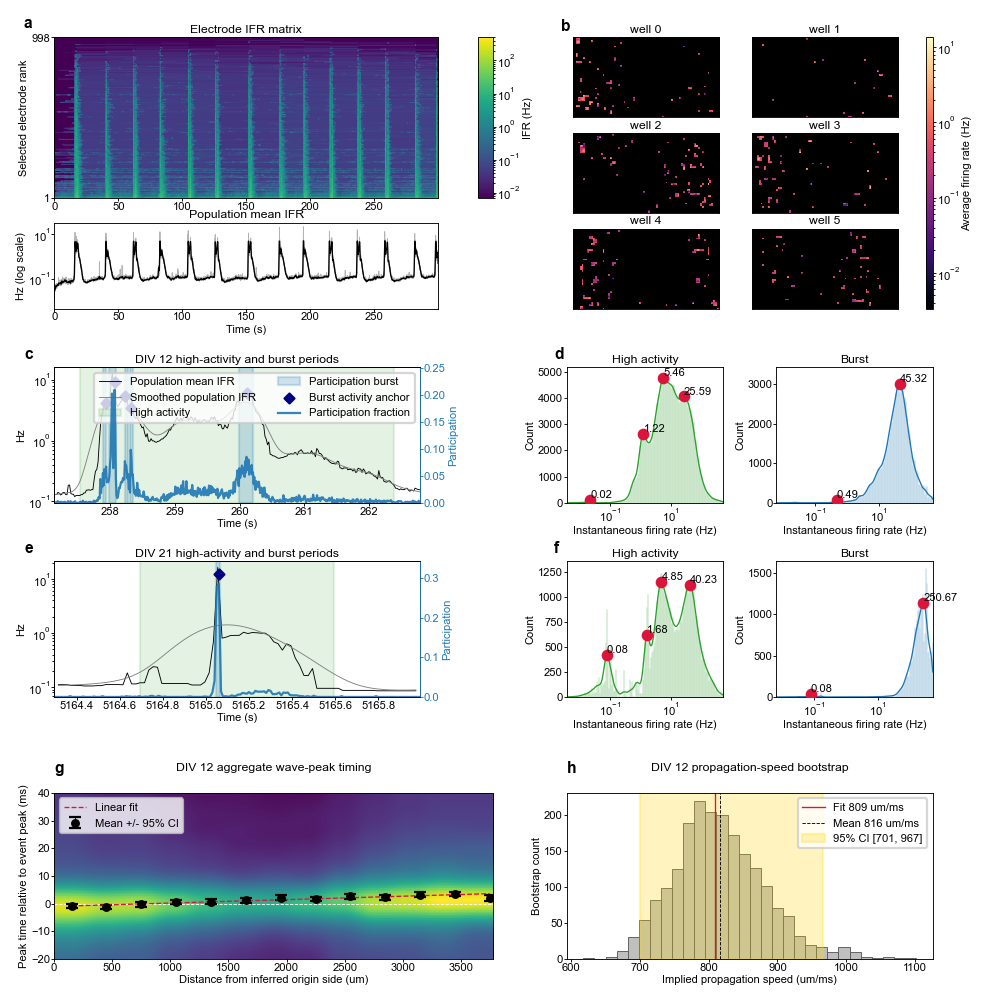

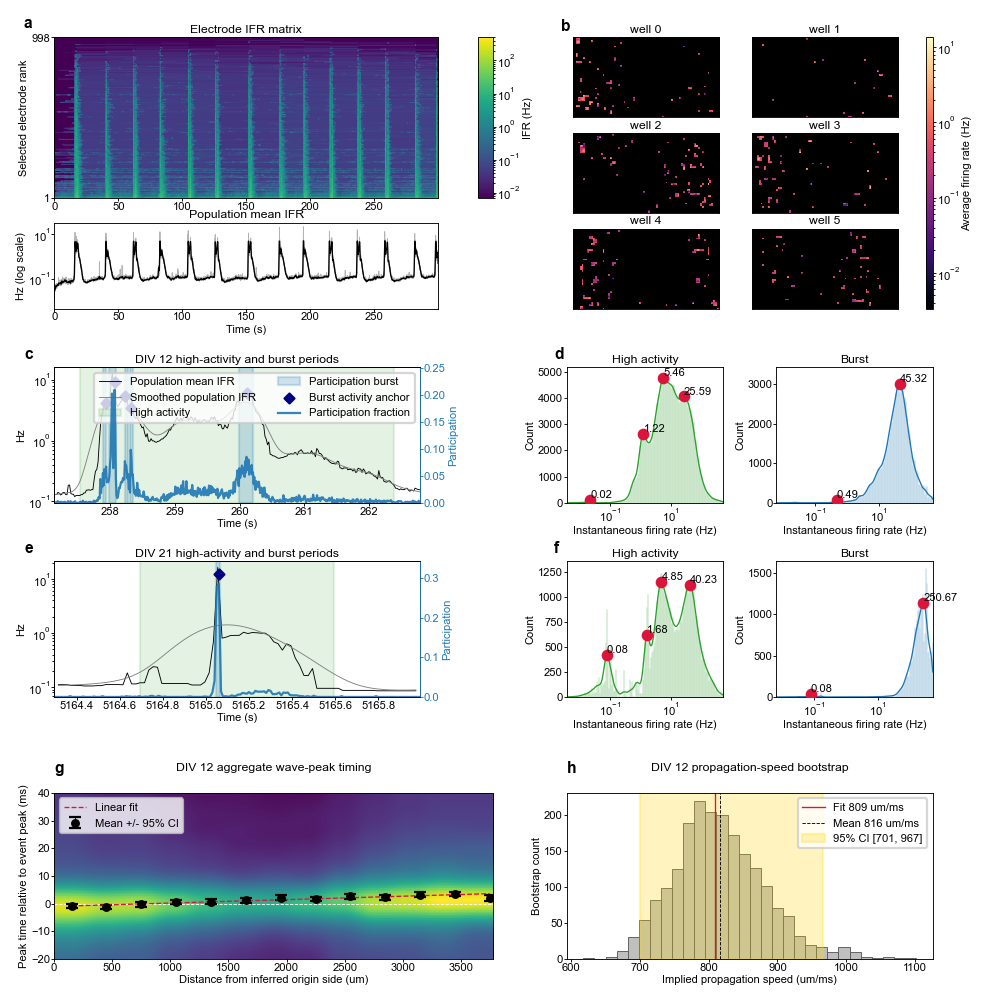

In [ ]:
fig2 = compose_figure(
    figure(width="two_column", height_mm=190, rows=[0.4, 0.2, 0.2, 0.3], row_gaps=[0.02, 0.02, 0.02], wspace=0, constrained_layout=False),
    [
        panel(
            "ifr_div12",
            label="a",
            loc=(0, 0, 1, 6),
            draw=draw_population_ifr_summary,
            data=figure2_data["single"][12]["population"],
            axes_factory=population_ifr_summary_axes_factory,
            options={
                "heatmap_title": "Electrode IFR matrix",
                "mean_title": "Population mean IFR",
                "show_titles": True,
                "mean_log_scale": True,
                "smooth_sigma_sec": SMOOTH_SIGMA_SEC,
                "show_legend": False,
            },
        ),
        panel(
            "grid_div12",
            label="b",
            loc=(0, 7, 1, 5),
            draw=draw_grid_panel,
            data=figure2_data["grid"][12],
            axes_factory=lambda fig, subplotspec: grid_avghz_panel_axes_factory(fig, subplotspec, n_items=len(WELLS), ncols=2),
            options={"compact": True, "show_legend": True},
        ),
        panel(
            "burst_div12",
            label="c",
            loc=(1, 0, 1, 5),
            draw=draw_high_activity_burst_windows,
            data=high_activity_panel_data(12),
            options={
                "n_windows": 1,
                "window_order": "peak_ifr",
                "pad_s": BURST_WINDOW_PAD_SEC,
                "show_legend": False,
                "title": "DIV 12 high-activity and burst periods",
                "compact": False,
            },
        ),
        panel(
            "kde_div12",
            label="d",
            loc=(1, 7, 1, 5),
            draw=draw_activity_kde_panel,
            data=figure2_data["activity_kde"][12],
            axes_factory=side_by_side_kde_axes_factory,
            options={"max_peak_labels": 6,
                     "show_legend": False},
        ),
        panel(
            "burst_div21",
            label="e",
            loc=(2, 0, 1, 5),
            draw=draw_high_activity_burst_windows,
            data=high_activity_panel_data(21),
            options={
                "n_windows": 1,
                "window_order": "peak_ifr",
                "pad_s": BURST_WINDOW_PAD_SEC,
                "show_legend": False,
                "title": "DIV 21 high-activity and burst periods",
                "compact": False,
            },
        ),
        panel(
            "kde_div21",
            label="f",
            loc=(2, 7, 1, 5),
            draw=draw_activity_kde_panel,
            data=figure2_data["activity_kde"][21],
            axes_factory=side_by_side_kde_axes_factory,
            options={"max_peak_labels": 6,
                     "show_legend": False},
        ),
        panel(
            "wave_timing_div12",
            label="g",
            loc=(3, 0, 1, 6),
            suptitle="DIV 12 aggregate wave-peak timing",
            draw=draw_wave_timing_panel,
            data=figure2_data["wave"][12]["result"],
            options={"compact": True, "show_colorbar": False, "show_legend": True},
        ),
        panel(
            "wave_bootstrap_div12",
            label="h",
            loc=(3, 7, 1, 5),
            suptitle="DIV 12 propagation-speed bootstrap",
            draw=draw_wave_bootstrap_panel,
            data=figure2_data["wave"][12]["result"],
            options={"compact": True, "show_legend": True},
        ),
    ],
)
fig2.fig

## Export

In [8]:
if SAVE_FIGURE:
    saved_paths = export_figure(fig2.fig, OUTPUT_DIR / "figure_2_burst_compilation", formats=("pdf", "svg", "png"))
    for path in saved_paths:
        print(path)

/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_burst_compilation.pdf
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_burst_compilation.svg
/Users/danielrebbin/Documents/GitHub/ephax/outputs/figure2_burst/figure_2_burst_compilation.png
